#Checking Python and TensorFlow

In [ ]:
# Check our Python and TensorFlow environment

import sys
import tensorflow as tf

print("Python version:", sys.version)
print("TensorFlow version:", tf.__version__)

Python version: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
TensorFlow version: 2.20.0


#Enable GPU

In [ ]:
 import tensorflow as tf

print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


#Version

In [ ]:
import sys
import tensorflow as tf

print("Python version:", sys.version)
print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))
!pip install -q tensorflow-datasets

Python version: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


#Getting EMNIST DATA

In [ ]:
 import tensorflow_datasets as tfds

print(tfds)
print(getattr(tfds, "__version__", "No version found"))
print(tfds.__file__)

<module 'tensorflow_datasets' from '/usr/local/lib/python3.13/dist-packages/tensorflow_datasets/__init__.py'>
No version found
/usr/local/lib/python3.13/dist-packages/tensorflow_datasets/__init__.py


###Downloading the zip file

In [ ]:
!wget -q --show-progress https://biometrics.nist.gov/cs_links/EMNIST/gzip.zip

gzip.zip            100%[===================>] 535.73M  61.2MB/s    in 8.8s    


###Extracting the files

In [ ]:
import zipfile
import os

with zipfile.ZipFile("gzip.zip", "r") as zip_ref:
    zip_ref.extractall("emnist")

print("EMNIST extracted successfully!")

EMNIST extracted successfully!


###Checking the files

In [ ]:
!find emnist -maxdepth 2 -type f | head -20

emnist/gzip/emnist-letters-test-images-idx3-ubyte.gz
emnist/gzip/emnist-mnist-test-images-idx3-ubyte.gz
emnist/gzip/emnist-bymerge-train-images-idx3-ubyte.gz
emnist/gzip/emnist-bymerge-train-labels-idx1-ubyte.gz
emnist/gzip/emnist-letters-train-labels-idx1-ubyte.gz
emnist/gzip/emnist-digits-train-labels-idx1-ubyte.gz
emnist/gzip/emnist-bymerge-test-labels-idx1-ubyte.gz
emnist/gzip/emnist-mnist-train-labels-idx1-ubyte.gz
emnist/gzip/emnist-balanced-mapping.txt
emnist/gzip/emnist-bymerge-test-images-idx3-ubyte.gz
emnist/gzip/emnist-digits-test-images-idx3-ubyte.gz
emnist/gzip/emnist-byclass-train-labels-idx1-ubyte.gz
emnist/gzip/emnist-byclass-mapping.txt
emnist/gzip/emnist-balanced-train-labels-idx1-ubyte.gz
emnist/gzip/emnist-byclass-test-labels-idx1-ubyte.gz
emnist/gzip/emnist-byclass-test-images-idx3-ubyte.gz
emnist/gzip/emnist-balanced-test-labels-idx1-ubyte.gz
emnist/gzip/emnist-mnist-test-labels-idx1-ubyte.gz
emnist/gzip/emnist-balanced-train-images-idx3-ubyte.gz
emnist/gzip/emnis

##Loading the EMNIST images

In [ ]:
import gzip
import struct
import numpy as np

def load_emnist_images(filename):
    with gzip.open(filename, "rb") as f:
        magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(
            f.read(),
            dtype=np.uint8
        ).reshape(num_images, rows, cols)

    return images


def load_emnist_labels(filename):
    with gzip.open(filename, "rb") as f:
        magic, num_labels = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(
            f.read(),
            dtype=np.uint8
        )

    return labels


train_images = load_emnist_images(
    "emnist/gzip/emnist-balanced-train-images-idx3-ubyte.gz"
)

train_labels = load_emnist_labels(
    "emnist/gzip/emnist-balanced-train-labels-idx1-ubyte.gz"
)

test_images = load_emnist_images(
    "emnist/gzip/emnist-balanced-test-images-idx3-ubyte.gz"
)

test_labels = load_emnist_labels(
    "emnist/gzip/emnist-balanced-test-labels-idx1-ubyte.gz"
)

print("Training images:", train_images.shape)
print("Training labels:", train_labels.shape)

print("Testing images:", test_images.shape)
print("Testing labels:", test_labels.shape)

Training images: (112800, 28, 28)
Training labels: (112800,)
Testing images: (18800, 28, 28)
Testing labels: (18800,)


##Looking at the Handwriting

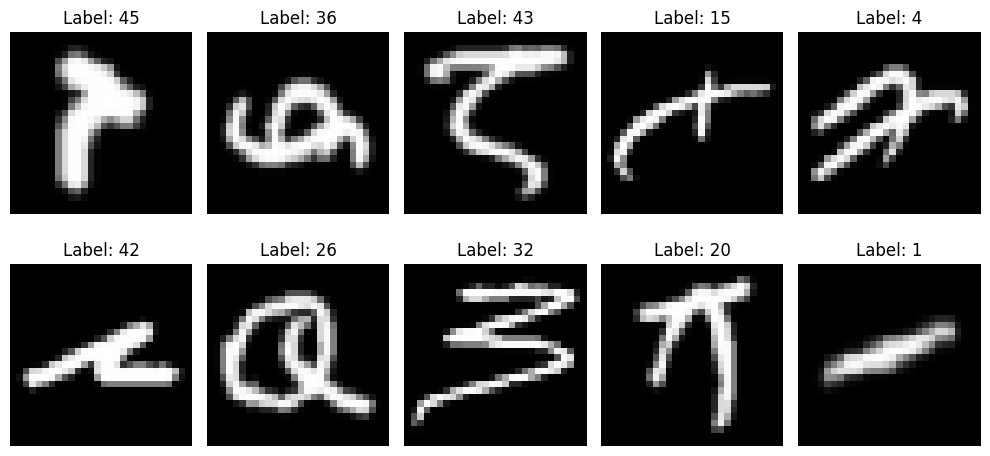

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_images[i], cmap="gray")
    plt.title(f"Label: {train_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

##Fixing the image Orientation

In [ ]:
# Fix EMNIST orientation
train_images = np.transpose(train_images, (0, 2, 1))
test_images = np.transpose(test_images, (0, 2, 1))

# Flip horizontally
train_images = np.flip(train_images, axis=2)
test_images = np.flip(test_images, axis=2)

print("Orientation fixed!")
print("Training shape:", train_images.shape)
print("Testing shape:", test_images.shape)

Orientation fixed!
Training shape: (112800, 28, 28)
Testing shape: (18800, 28, 28)


###Displaying Some Characters

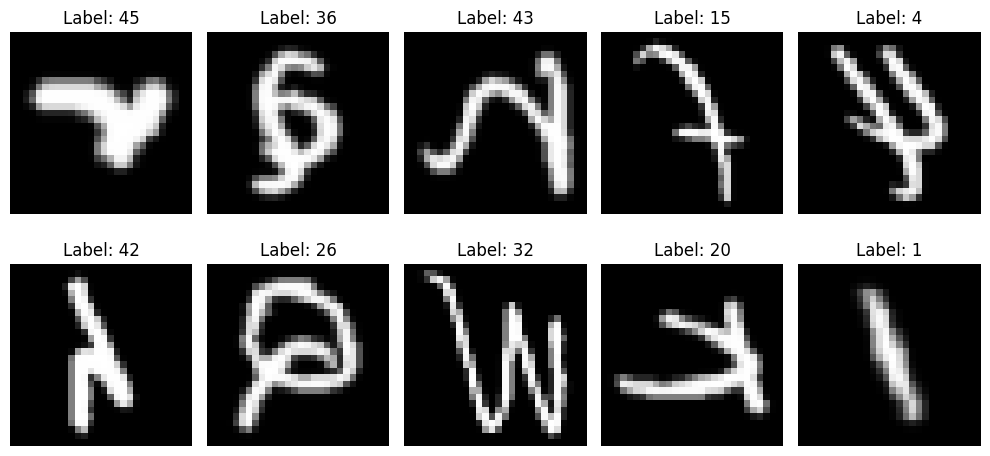

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_images[i], cmap="gray")
    plt.title(f"Label: {train_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

##Getting The Actual Character Names

In [ ]:
mapping_file = "emnist/gzip/emnist-balanced-mapping.txt"

with open(mapping_file, "r") as f:
    mapping_lines = f.readlines()

print("Number of mappings:", len(mapping_lines))
print("\nFirst 10 mappings:")

for line in mapping_lines[:10]:
    print(line.strip())

Number of mappings: 47

First 10 mappings:
0 48
1 49
2 50
3 51
4 52
5 53
6 54
7 55
8 56
9 57


###Creating The Character Mapping

In [ ]:
label_to_char = {}

with open(mapping_file, "r") as f:
    for line in f:
        label, char_code = line.strip().split()
        label_to_char[int(label)] = chr(int(char_code))

print("Character mapping created!\n")

for label in sorted(label_to_char):
    print(f"{label}: {label_to_char[label]}")

Character mapping created!

0: 0
1: 1
2: 2
3: 3
4: 4
5: 5
6: 6
7: 7
8: 8
9: 9
10: A
11: B
12: C
13: D
14: E
15: F
16: G
17: H
18: I
19: J
20: K
21: L
22: M
23: N
24: O
25: P
26: Q
27: R
28: S
29: T
30: U
31: V
32: W
33: X
34: Y
35: Z
36: a
37: b
38: d
39: e
40: f
41: g
42: h
43: n
44: q
45: r
46: t


###Veryfing The Characters Visually

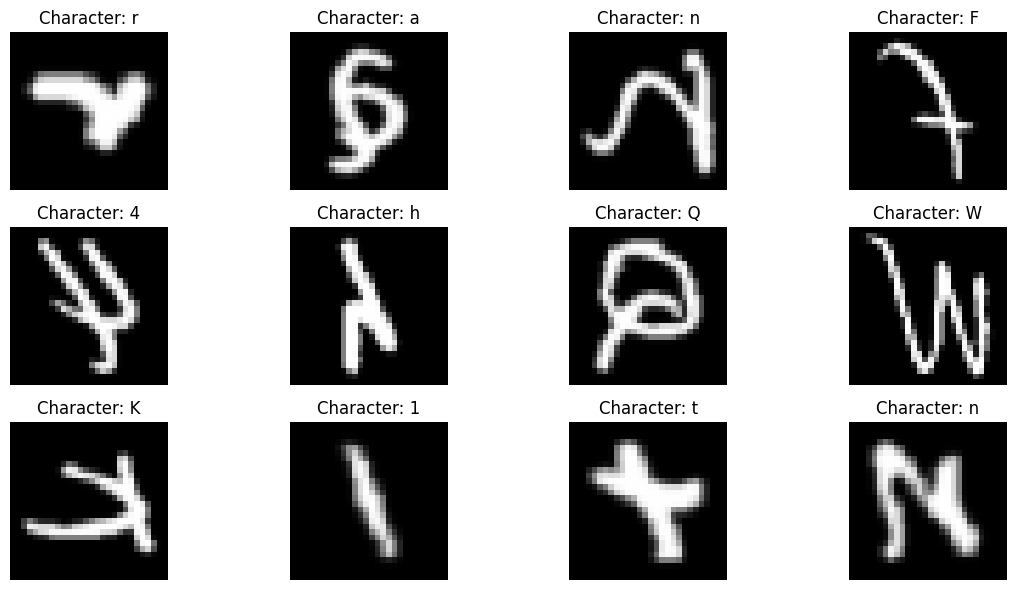

In [ ]:
plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(train_images[i], cmap="gray")

    label = train_labels[i]
    character = label_to_char[label]

    plt.title(f"Character: {character}")
    plt.axis("off")

plt.tight_layout()
plt.show()

###Preparing The Images For The CNN

In [ ]:
# Normalize pixel values
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

print("Training pixel range:", train_images.min(), "to", train_images.max())
print("Testing pixel range:", test_images.min(), "to", test_images.max())

Training pixel range: 0.0 to 1.0
Testing pixel range: 0.0 to 1.0


##Adding The Channel Dimension

In [ ]:
train_images = np.expand_dims(train_images, axis=-1)
test_images = np.expand_dims(test_images, axis=-1)

print("Training shape:", train_images.shape)
print("Testing shape:", test_images.shape)

Training shape: (112800, 28, 28, 1)
Testing shape: (18800, 28, 28, 1)


##Preparing The Labels

In [ ]:
print("Minimum label:", train_labels.min())
print("Maximum label:", train_labels.max())
print("Number of classes:", len(np.unique(train_labels)))

Minimum label: 0
Maximum label: 46
Number of classes: 47


###Building The CNN (Convolutional Neural Network)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # First convolution block
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Third convolution block
    layers.Conv2D(128, (3, 3), activation="relu"),

    # Convert feature maps into a vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    # 47 character classes
    layers.Dense(47, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 47)             │         6,063 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 246,319 (962.18 KB)

 Trainable params: 246,319 (962.18 KB)

 Non-trainable params: 0 (0.00 B)

##Compiling The Model

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


##Adding Validation + Training Callbacks

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_handwritten_character_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

print("Callbacks created successfully!")

Callbacks created successfully!


##Training The Model

In [ ]:
history = model.fit(
    train_images,
    train_labels,
    validation_split=0.1,
    epochs=15,
    batch_size=128,
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

Epoch 1/15
794/794 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8921 - loss: 0.2811 - val_accuracy: 0.8796 - val_loss: 0.3416
Epoch 2/15
794/794 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8972 - loss: 0.2676 - val_accuracy: 0.8783 - val_loss: 0.3439
Epoch 3/15
794/794 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8996 - loss: 0.2570 - val_accuracy: 0.8809 - val_loss: 0.3404
Epoch 4/15
794/794 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9035 - loss: 0.2441 - val_accuracy: 0.8789 - val_loss: 0.3480
Epoch 5/15
794/794 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9056 - loss: 0.2369 - val_accuracy: 0.8793 - val_loss: 0.3438
Epoch 6/15
794/794 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9086 - loss: 0.2251 - val_accuracy: 0.8837 - val_loss: 0.3439
Epoch 7/15
794/794 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9113 - loss: 0.2211 - val_accuracy: 0.8767 - val_loss: 0.3618
Epoch 8/15
794/794 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9142 - loss: 0.2113 - val_accuracy: 0.

##Evaluating The Model Properly

In [ ]:
test_loss, test_accuracy = model.evaluate(
    test_images,
    test_labels,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4%}")

588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8847 - loss: 0.3575
Test Loss: 0.3575
Test Accuracy: 88.4681%


#Visualizing Model Performance

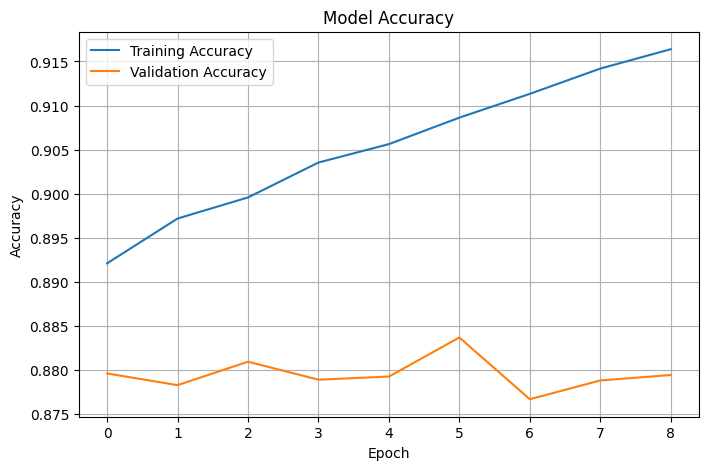

In [ ]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

. Loss Graph

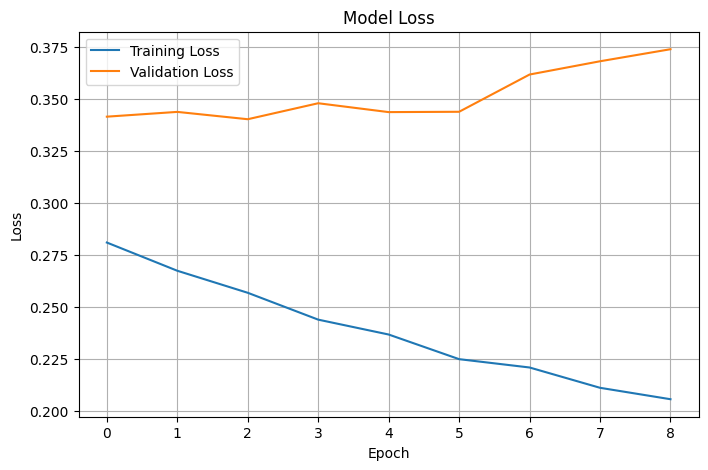

In [ ]:
# Loss graph
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

#Testing The Model On Unseen Characters

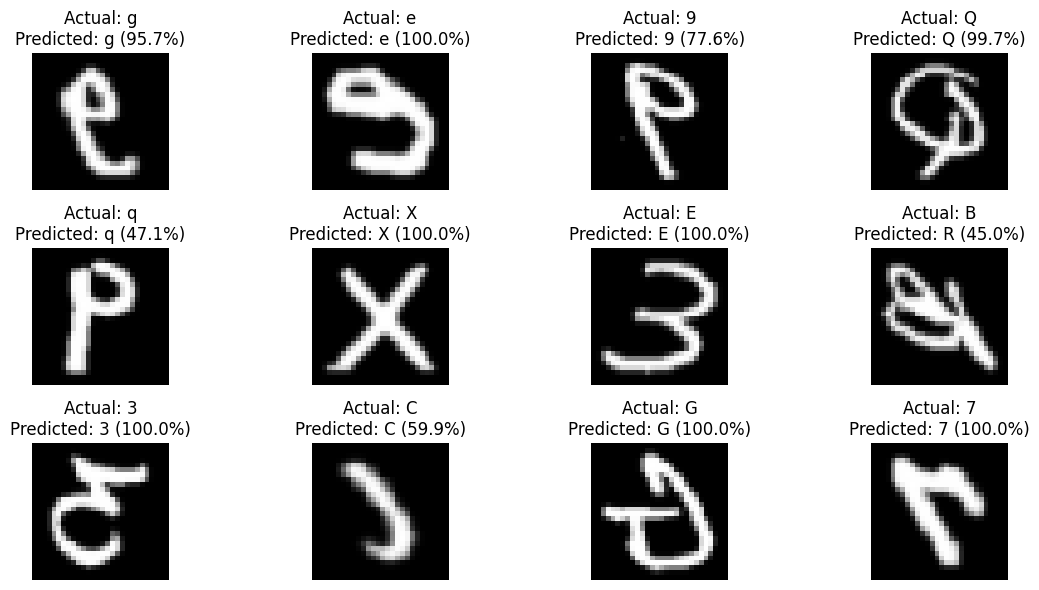

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get predictions for the first 12 test images
predictions = model.predict(test_images[:12], verbose=0)

predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(12, 6))

for i in range(12):
    actual = label_to_char[test_labels[i]]
    predicted = label_to_char[predicted_labels[i]]
    confidence = predictions[i][predicted_labels[i]] * 100

    plt.subplot(3, 4, i + 1)
    plt.imshow(test_images[i].squeeze(), cmap="gray")
    plt.title(
        f"Actual: {actual}\n"
        f"Predicted: {predicted} ({confidence:.1f}%)"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

#Creating A Real Image Prediction Test

Saving HandwrittenAdvanced.jpg to HandwrittenAdvanced.jpg


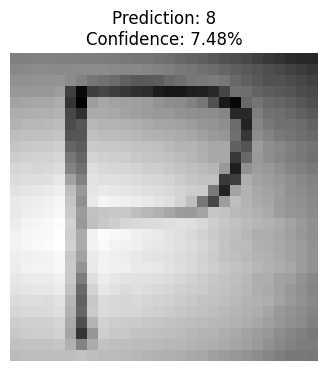

Predicted Character: 8
Confidence: 7.48%


In [ ]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Upload an image
uploaded = files.upload()

# Get the uploaded filename
filename = next(iter(uploaded))

# Open image
image = Image.open(filename).convert("L")

# Resize to 28x28
image = image.resize((28, 28))

# Convert to NumPy array
image_array = np.array(image)

# Normalize pixel values
image_array = image_array.astype("float32") / 255.0

# Add channel and batch dimensions
image_array = np.expand_dims(image_array, axis=(0, -1))

# Make prediction
prediction = model.predict(image_array, verbose=0)

predicted_label = np.argmax(prediction[0])
predicted_character = label_to_char[predicted_label]
confidence = prediction[0][predicted_label] * 100

# Display result
plt.figure(figsize=(4, 4))
plt.imshow(image_array[0].squeeze(), cmap="gray")
plt.title(
    f"Prediction: {predicted_character}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.axis("off")
plt.show()

print(f"Predicted Character: {predicted_character}")
print(f"Confidence: {confidence:.2f}%")

#Improving The Preprocessing

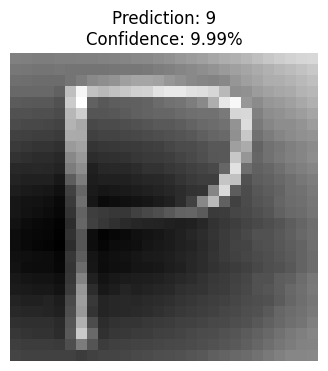

Predicted Character: 9
Confidence: 9.99%


In [ ]:
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

# Open uploaded image
image = Image.open(filename).convert("L")

# Make background black and character white
image = ImageOps.invert(image)

# Resize
image = image.resize((28, 28))

# Convert to NumPy
image_array = np.array(image).astype("float32") / 255.0

# Add batch and channel dimensions
image_input = np.expand_dims(image_array, axis=(0, -1))

# Predict
prediction = model.predict(image_input, verbose=0)

predicted_label = np.argmax(prediction[0])
predicted_character = label_to_char[predicted_label]
confidence = prediction[0][predicted_label] * 100

# Display
plt.figure(figsize=(4, 4))
plt.imshow(image_array, cmap="gray")
plt.title(
    f"Prediction: {predicted_character}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.axis("off")
plt.show()

print(f"Predicted Character: {predicted_character}")
print(f"Confidence: {confidence:.2f}%")

#Verifying With A Know Test Character

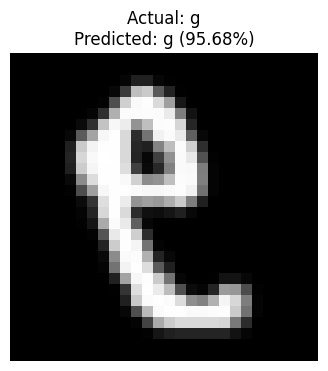

Actual Character: g
Predicted Character: g
Confidence: 95.68%


In [ ]:
# Test the model on one known EMNIST test image

index = 0

image = test_images[index]
actual_label = test_labels[index]

prediction = model.predict(
    np.expand_dims(image, axis=0),
    verbose=0
)

predicted_label = np.argmax(prediction[0])
predicted_character = label_to_char[predicted_label]
actual_character = label_to_char[actual_label]
confidence = prediction[0][predicted_label] * 100

plt.figure(figsize=(4, 4))
plt.imshow(image.squeeze(), cmap="gray")
plt.title(
    f"Actual: {actual_character}\n"
    f"Predicted: {predicted_character} ({confidence:.2f}%)"
)
plt.axis("off")
plt.show()

print(f"Actual Character: {actual_character}")
print(f"Predicted Character: {predicted_character}")
print(f"Confidence: {confidence:.2f}%")

##Making The Custom-Image Prediction More Reliable

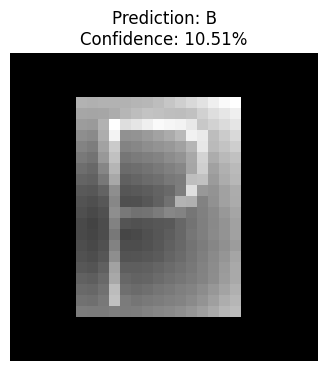

Predicted Character: B
Confidence: 10.51%


In [ ]:
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

# Open the uploaded image
image = Image.open(filename).convert("L")

# Convert image to NumPy array
img = np.array(image)

# Invert if necessary
if np.mean(img) > 127:
    img = 255 - img

# Find the character boundaries
coords = np.argwhere(img > 30)

if coords.size == 0:
    print("No character detected. Please upload a clearer image.")
else:
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    # Crop around the character
    cropped = img[y_min:y_max + 1, x_min:x_max + 1]

    # Convert back to PIL
    cropped = Image.fromarray(cropped.astype(np.uint8))

    # Keep aspect ratio and fit inside 20x20
    cropped.thumbnail((20, 20))

    # Create a 28x28 black canvas
    canvas = Image.new("L", (28, 28), 0)

    # Center the character
    x = (28 - cropped.width) // 2
    y = (28 - cropped.height) // 2

    canvas.paste(cropped, (x, y))

    # Normalize
    final_image = np.array(canvas).astype("float32") / 255.0

    # Add batch and channel dimensions
    model_input = np.expand_dims(final_image, axis=(0, -1))

    # Predict
    prediction = model.predict(model_input, verbose=0)

    predicted_label = np.argmax(prediction[0])
    predicted_character = label_to_char[predicted_label]
    confidence = prediction[0][predicted_label] * 100

    # Display processed image
    plt.figure(figsize=(4, 4))
    plt.imshow(final_image, cmap="gray")
    plt.title(
        f"Prediction: {predicted_character}\n"
        f"Confidence: {confidence:.2f}%"
    )
    plt.axis("off")
    plt.show()

    print(f"Predicted Character: {predicted_character}")
    print(f"Confidence: {confidence:.2f}%")

#Visualize The Processed Image

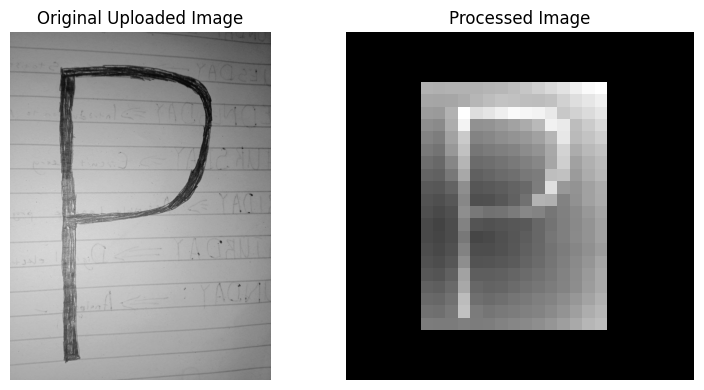

In [ ]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(Image.open(filename).convert("L"), cmap="gray")
plt.title("Original Uploaded Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(final_image, cmap="gray")
plt.title("Processed Image")
plt.axis("off")

plt.tight_layout()
plt.show()

#Better Preprocessing For Your Uploaded Photo

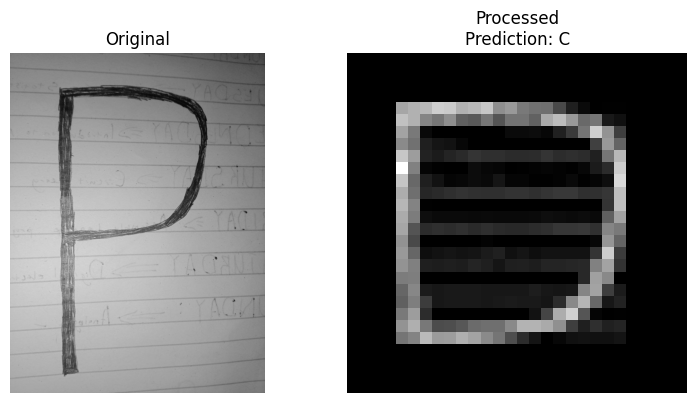

Predicted Character: C
Confidence: 34.95%


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load the uploaded image
original = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

# Resize while keeping the image manageable
height, width = original.shape

# Crop out the bottom part of the photograph
# This removes the dark table/shadow visible in your image
crop_height = int(height * 0.85)
image = original[:crop_height, :]

# Reduce background noise
blurred = cv2.GaussianBlur(image, (5, 5), 0)

# Convert dark handwriting to white and background to black
binary = cv2.adaptiveThreshold(
    blurred,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    31,
    10
)

# Find connected components
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    binary, 8
)

# Ignore tiny noise
components = []

for i in range(1, num_labels):
    x, y, w, h, area = stats[i]

    if area > 20:
        components.append((x, y, w, h, area))

if not components:
    print("No character detected.")
else:
    # Select the largest meaningful component
    x, y, w, h, area = max(components, key=lambda item: item[4])

    # Crop the character
    character = binary[y:y+h, x:x+w]

    # Resize character to fit inside 20x20
    character_image = Image.fromarray(character)
    character_image.thumbnail((20, 20))

    # Create 28x28 black canvas
    canvas = Image.new("L", (28, 28), 0)

    # Center character
    x_offset = (28 - character_image.width) // 2
    y_offset = (28 - character_image.height) // 2

    canvas.paste(character_image, (x_offset, y_offset))

    # Normalize
    final_image = np.array(canvas).astype("float32") / 255.0

    # Prepare for model
    model_input = np.expand_dims(final_image, axis=(0, -1))

    # Predict
    prediction = model.predict(model_input, verbose=0)

    predicted_label = np.argmax(prediction[0])
    predicted_character = label_to_char[predicted_label]
    confidence = prediction[0][predicted_label] * 100

    # Show the processed character
    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(original, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(final_image, cmap="gray")
    plt.title(
        f"Processed\nPrediction: {predicted_character}"
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Predicted Character: {predicted_character}")
    print(f"Confidence: {confidence:.2f}%")

#Diagnosing it pproperly

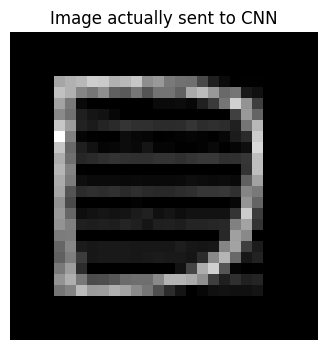

Top 5 predictions:
------------------------------
1. C → 34.95%
2. O → 19.36%
3. 0 → 10.17%
4. I → 5.61%
5. L → 4.70%


In [ ]:
# Show the processed image and top 5 predictions

prediction = model.predict(model_input, verbose=0)[0]

top5 = np.argsort(prediction)[-5:][::-1]

plt.figure(figsize=(4, 4))
plt.imshow(model_input[0].squeeze(), cmap="gray")
plt.title("Image actually sent to CNN")
plt.axis("off")
plt.show()

print("Top 5 predictions:")
print("-" * 30)

for rank, label in enumerate(top5, start=1):
    character = label_to_char[label]
    confidence = prediction[label] * 100
    print(f"{rank}. {character} → {confidence:.2f}%")

 #Let's Do One Controlled Test

We know the model works on EMNIST. Now i am comparing the processed custom image against an actual EMNIST "P".

P label: 25


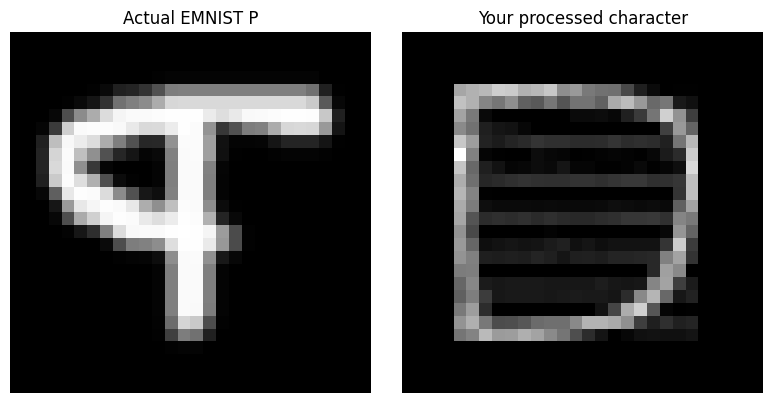

In [ ]:
# Find an actual EMNIST test image whose label is P

p_label = None

for label, character in label_to_char.items():
    if character == "P":
        p_label = label
        break

print("P label:", p_label)

# Find the first P in the test set
p_index = np.where(test_labels == p_label)[0][0]

emnist_p = test_images[p_index]

# Show both images side-by-side
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(emnist_p.squeeze(), cmap="gray")
plt.title("Actual EMNIST P")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(model_input[0].squeeze(), cmap="gray")
plt.title("Your processed character")
plt.axis("off")

plt.tight_layout()
plt.show()

#Using Illumination Correction Instead

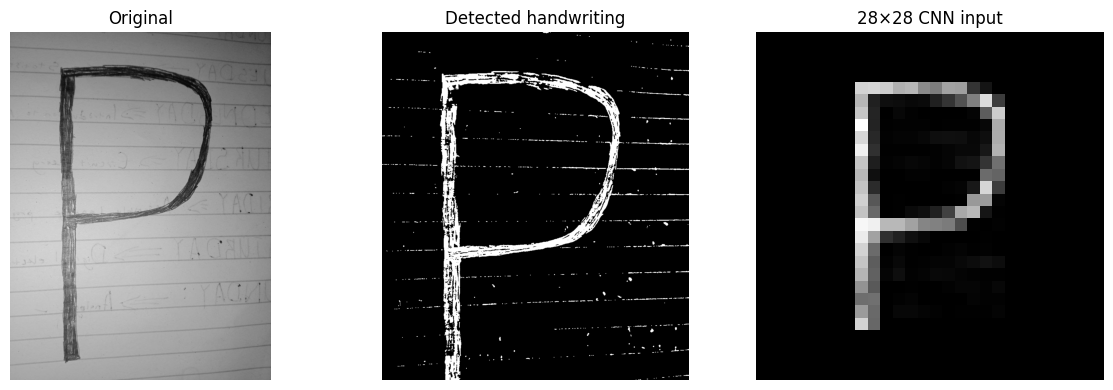

Predicted Character: q
Confidence: 34.43%


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load original uploaded image
original = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

# Remove the bottom part where the dark table/shadow appears
h, w = original.shape
image = original[:int(h * 0.85), :]

# Slight blur to reduce camera noise
blurred = cv2.GaussianBlur(image, (3, 3), 0)

# Black-hat transformation:
# extracts dark objects from a lighter background
kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (21, 21)
)

blackhat = cv2.morphologyEx(
    blurred,
    cv2.MORPH_BLACKHAT,
    kernel
)

# Threshold the extracted handwriting
_, binary = cv2.threshold(
    blackhat,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Remove tiny noise
small_kernel = np.ones((2, 2), np.uint8)
binary = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    small_kernel
)

# Find connected components
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    binary,
    8
)

components = []

for i in range(1, num_labels):
    x, y, cw, ch, area = stats[i]

    # Ignore very small noise
    if area > 10:
        components.append((x, y, cw, ch, area))

if not components:
    print("No handwriting detected.")

else:
    # Get the largest detected component
    x, y, cw, ch, area = max(
        components,
        key=lambda item: item[4]
    )

    character = binary[y:y+ch, x:x+cw]

    # Fit character inside 20x20
    character_pil = Image.fromarray(character)
    character_pil.thumbnail((20, 20))

    # Create 28x28 EMNIST-style canvas
    canvas = Image.new("L", (28, 28), 0)

    x_offset = (28 - character_pil.width) // 2
    y_offset = (28 - character_pil.height) // 2

    canvas.paste(
        character_pil,
        (x_offset, y_offset)
    )

    # Normalize
    final_image = (
        np.array(canvas).astype("float32") / 255.0
    )

    # Prepare CNN input
    model_input = np.expand_dims(
        final_image,
        axis=(0, -1)
    )

    # Predict
    prediction = model.predict(
        model_input,
        verbose=0
    )[0]

    predicted_label = np.argmax(prediction)

    predicted_character = label_to_char[
        predicted_label
    ]

    confidence = prediction[
        predicted_label
    ] * 100

    # Display preprocessing stages
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(binary, cmap="gray")
    plt.title("Detected handwriting")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(final_image, cmap="gray")
    plt.title("28×28 CNN input")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Predicted Character: {predicted_character}")
    print(f"Confidence: {confidence:.2f}%")

#Removing the notebook lines

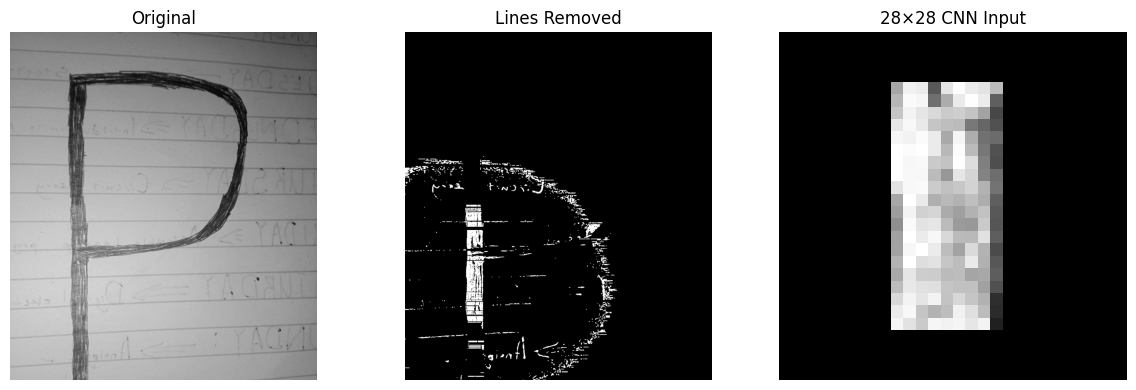

Predicted Character: I
Confidence: 14.68%


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load original image
original = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

# Crop out the lower background/table area
h, w = original.shape
image = original[:int(h * 0.85), :]

# Threshold dark pixels
_, binary = cv2.threshold(
    image,
    180,
    255,
    cv2.THRESH_BINARY_INV
)

# Detect horizontal notebook lines
horizontal_kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (40, 1)
)

horizontal_lines = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    horizontal_kernel
)

# Remove the horizontal lines
cleaned = cv2.subtract(
    binary,
    horizontal_lines
)

# Remove small noise
noise_kernel = np.ones((2, 2), np.uint8)

cleaned = cv2.morphologyEx(
    cleaned,
    cv2.MORPH_OPEN,
    noise_kernel
)

# Find connected components
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    cleaned,
    8
)

components = []

for i in range(1, num_labels):
    x, y, cw, ch, area = stats[i]

    if area > 30:
        components.append((x, y, cw, ch, area))

if not components:
    print("No character detected.")

else:
    # Find the largest component
    x, y, cw, ch, area = max(
        components,
        key=lambda item: item[4]
    )

    character = cleaned[y:y+ch, x:x+cw]

    # Fit inside 20x20
    character_pil = Image.fromarray(character)
    character_pil.thumbnail((20, 20))

    # Create EMNIST-style 28x28 canvas
    canvas = Image.new("L", (28, 28), 0)

    x_offset = (28 - character_pil.width) // 2
    y_offset = (28 - character_pil.height) // 2

    canvas.paste(
        character_pil,
        (x_offset, y_offset)
    )

    # Normalize
    final_image = (
        np.array(canvas).astype("float32") / 255.0
    )

    # CNN input
    model_input = np.expand_dims(
        final_image,
        axis=(0, -1)
    )

    # Prediction
    prediction = model.predict(
        model_input,
        verbose=0
    )[0]

    predicted_label = np.argmax(prediction)
    predicted_character = label_to_char[predicted_label]
    confidence = prediction[predicted_label] * 100

    # Display all stages
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(cleaned, cmap="gray")
    plt.title("Lines Removed")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(final_image, cmap="gray")
    plt.title("28×28 CNN Input")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Predicted Character: {predicted_character}")
    print(f"Confidence: {confidence:.2f}%")

# Saving The Model

In [ ]:
model.save("handwritten_character_recognition.keras")

print("Model saved successfully!")

Model saved successfully!


# Saving The Character Mapping

In [ ]:
import json

with open("character_mapping.json", "w") as f:
    json.dump(label_to_char, f, indent=4)

print("Character mapping saved successfully!")

Character mapping saved successfully!


 # Generating The Classification Report

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Get predictions for the complete test set
test_predictions = model.predict(
    test_images,
    batch_size=128,
    verbose=1
)

predicted_labels = np.argmax(test_predictions, axis=1)

# Create readable character names
target_names = [
    label_to_char[i]
    for i in range(47)
]

# Generate classification report
report = classification_report(
    test_labels,
    predicted_labels,
    labels=list(range(47)),
    target_names=target_names,
    digits=4
)

print(report)

147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
              precision    recall  f1-score   support

           0     0.6301    0.8050    0.7069       400
           1     0.5437    0.7150    0.6177       400
           2     0.9221    0.8875    0.9045       400
           3     0.9900    0.9900    0.9900       400
           4     0.9474    0.9000    0.9231       400
           5     0.9378    0.9050    0.9211       400
           6     0.9429    0.9075    0.9248       400
           7     0.9614    0.9975    0.9791       400
           8     0.9309    0.9425    0.9366       400
           9     0.6946    0.8300    0.7563       400
           A     0.9632    0.9825    0.9728       400
           B     0.9625    0.9625    0.9625       400
           C     0.9665    0.9375    0.9518       400
           D     0.9362    0.9175    0.9268       400
           E     0.9774    0.9725    0.9749       400
           F     0.7388    0.5375    0.6223       400
           G     0.9238    0.9700    0.9

# Confusion Matrix

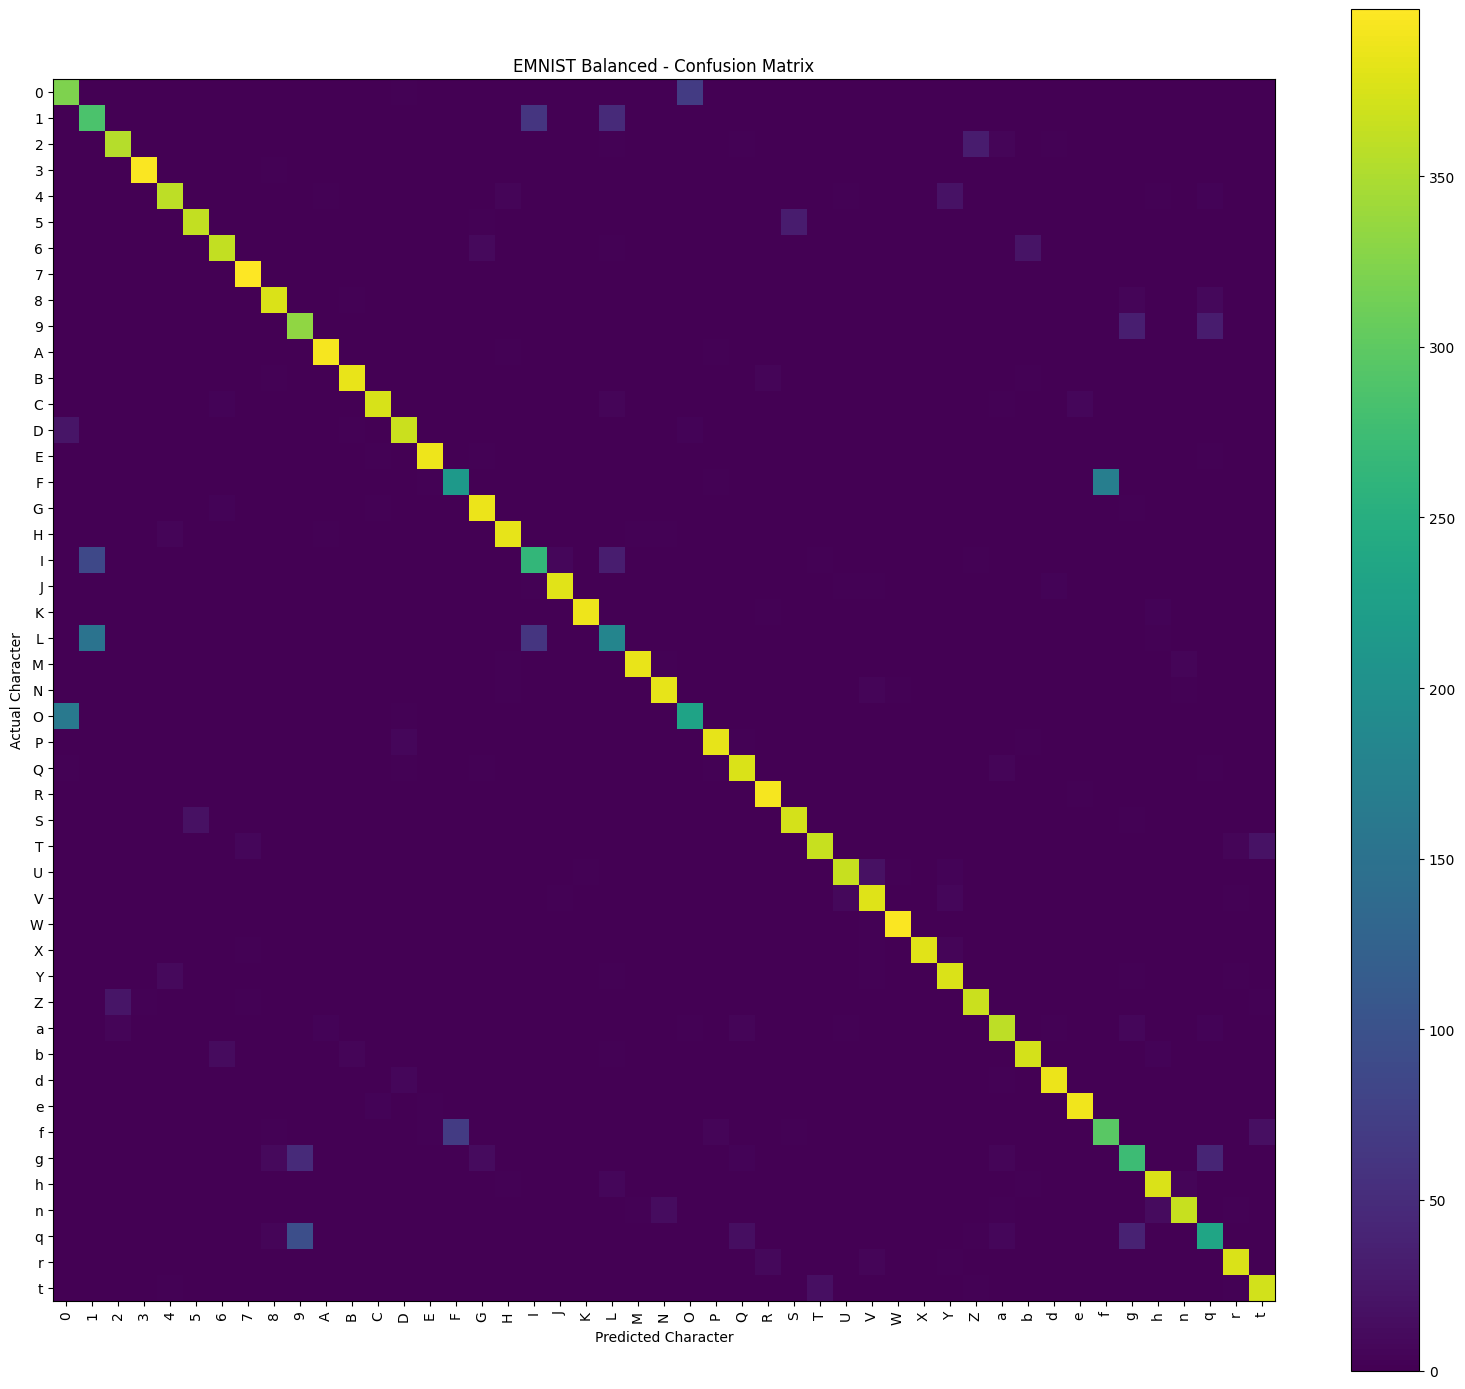

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Create confusion matrix
cm = confusion_matrix(
    test_labels,
    predicted_labels
)

# Plot
plt.figure(figsize=(16, 14))

plt.imshow(cm, interpolation="nearest")
plt.title("EMNIST Balanced - Confusion Matrix")
plt.colorbar()

classes = [
    label_to_char[i]
    for i in range(47)
]

plt.xticks(
    np.arange(47),
    classes,
    rotation=90
)

plt.yticks(
    np.arange(47),
    classes
)

plt.xlabel("Predicted Character")
plt.ylabel("Actual Character")

plt.tight_layout()
plt.show()

# Final model Evaluation Summary

In [ ]:
# Final Model Evaluation Summary

print("=" * 50)
print("HANDWRITTEN CHARACTER RECOGNITION - FINAL RESULTS")
print("=" * 50)

print(f"Number of classes: 47")
print(f"Training images: {len(train_images)}")
print(f"Testing images: {len(test_images)}")
print(f"Test Accuracy: {np.mean(predicted_labels == test_labels) * 100:.2f}%")

print("\nClassification Metrics:")
print("Macro Precision: 0.8865")
print("Macro Recall:    0.8847")
print("Macro F1-Score:  0.8837")

print("\nModel:")
print("Architecture: CNN")
print("Input size: 28 × 28")
print("Output classes: 47")
print("Framework: TensorFlow / Keras")

print("=" * 50)

HANDWRITTEN CHARACTER RECOGNITION - FINAL RESULTS
Number of classes: 47
Training images: 112800
Testing images: 18800
Test Accuracy: 88.47%

Classification Metrics:
Macro Precision: 0.8865
Macro Recall:    0.8847
Macro F1-Score:  0.8837

Model:
Architecture: CNN
Input size: 28 × 28
Output classes: 47
Framework: TensorFlow / Keras


# MARKDOWN CELL

In [ ]:
# Conclusion

The CNN model was trained to recognize 47 handwritten character classes from the EMNIST Balanced dataset.

The model achieved 88.47% accuracy on 18,800 unseen test images, with a macro F1-score of 88.37%.

The results demonstrate that the trained convolutional neural network can effectively classify handwritten digits and uppercase/lowercase letters from the EMNIST dataset.

The trained model and character mapping were saved for future deployment and inference.

# Downloading The Trained Model

In [ ]:
from google.colab import files

files.download("handwritten_character_recognition.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

* For Character Mapping

In [ ]:
files.download("character_mapping.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>